<a href="https://colab.research.google.com/github/Lexi-Zhou/stats201-project-zzz/blob/main/Code/W5_1_RF_LR_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Load data


In [ ]:
base_path = '/content/drive/MyDrive/Colab Notebooks/stats201_final_project/Week_4/'

file_dict = {
    'stem_poor': '18_RMP_stem_poor.csv',
    'stem_average': '18_RMP_stem_average.csv',
    'stem_good': '18_RMP_stem_good.csv',
    'humanities_poor': '18_RMP_humanities_poor.csv',
    'humanities_average': '18_RMP_humanities_average.csv',
    'humanities_good': '18_RMP_humanities_good.csv'
}

# 2. Experiment


## 2.1 function
text-processing + modeling configuration

In [ ]:
def run_experiment(
    df,
    text_col,
    ngram_range=(1, 1),
    max_features=2000,
    random_state=42
):
    """
    Runs TF-IDF + RF + LR on a given text column and ngram setting.
    Returns metrics + feature-level outputs for heatmaps.
    """

    # 1. Prepare X and y
    X = df[text_col].fillna('')
    y = df['prof_gender_finalized']

    # 2. Vectorization
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
    )
    X_vec = vectorizer.fit_transform(X)
    feature_names = vectorizer.get_feature_names_out()

    # 3. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, y, test_size=0.2, random_state=random_state, stratify=y
    )

    # 4. Random Forest
    rf = RandomForestClassifier(
        random_state=random_state,
        oob_score=True
    )
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]

    rf_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_rf),
        'oob_score': rf.oob_score_
    }

    rf_importance_df = pd.DataFrame({
        'Word': feature_names,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)

    # 5. Logistic Regression
    lr = LogisticRegression(
        solver='liblinear',
        random_state=random_state
    )
    lr.fit(X_train, y_train)

    y_pred_lr = lr.predict(X_test)
    y_prob_lr = lr.predict_proba(X_test)[:, 1]

    lr_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_lr),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_lr)
    }

    coef = lr.coef_[0]
    lr_coef_df = pd.DataFrame({
        'Word': feature_names,
        'LR_Coefficient': coef,
        'Direction': np.where(coef > 0, 'Male', 'Female')
    }).sort_values('LR_Coefficient', key=np.abs, ascending=False)

    return {
        'rf_metrics': rf_metrics,
        'lr_metrics': lr_metrics,
        'rf_importance': rf_importance_df,
        'lr_coefficients': lr_coef_df
    }

## 2.2 configurations

unigram, unigram+bigram, NEG_ prefix

In [ ]:
EXPERIMENTS = {
    'unigram': {
        'text_col': 'comments_scrubbed',
        'ngram_range': (1, 1)
    },
    'unigram_bigram': {
        'text_col': 'comments_scrubbed',
        'ngram_range': (1, 2)
    },
    'neg_prefixed': {
        'text_col': 'comments_scrubbed_neg',
        'ngram_range': (1, 1)
    }
}

## 2.3 processe

loop over datasets * experimental conditions

In [ ]:
all_results = {}

for dataset_label, filename in file_dict.items():
    print(f"\n=== Processing dataset: {dataset_label} ===")
    df = pd.read_csv(os.path.join(base_path, filename))

    all_results[dataset_label] = {}

    for exp_name, config in EXPERIMENTS.items():
        print(f"  → Experiment: {exp_name}")

        results = run_experiment(
            df=df,
            text_col=config['text_col'],
            ngram_range=config['ngram_range']
        )

        all_results[dataset_label][exp_name] = results



=== Processing dataset: stem_poor ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: stem_average ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: stem_good ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: humanities_poor ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: humanities_average ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: humanities_good ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed


# 3. Output

## 3.1 Performance evaluation

Accuracy, F1-score, ROC-AUC

In [ ]:
performance_records = []

for dataset_label, dataset_results in all_results.items():
    for exp_name, results in dataset_results.items():

        performance_records.append({
            'dataset': dataset_label,
            'experiment': exp_name,
            'model': 'RandomForest',
            'accuracy': results['rf_metrics']['accuracy'],
            'f1_score': results['rf_metrics']['f1'],
            'roc_auc': results['rf_metrics']['roc_auc']
        })

        performance_records.append({
            'dataset': dataset_label,
            'experiment': exp_name,
            'model': 'LogisticRegression',
            'accuracy': results['lr_metrics']['accuracy'],
            'f1_score': results['lr_metrics']['f1'],
            'roc_auc': results['lr_metrics']['roc_auc']
        })

performance_df = pd.DataFrame(performance_records)
performance_df

,dataset,experiment,model,accuracy,f1_score,roc_auc
0,stem_poor,unigram,RandomForest,0.624390,0.725979,0.610735
1,stem_poor,unigram,LogisticRegression,0.604878,0.719723,0.675784
2,stem_poor,unigram_bigram,RandomForest,0.648780,0.746479,0.637059
3,stem_poor,unigram_bigram,LogisticRegression,0.634146,0.738676,0.662353
4,stem_poor,neg_prefixed,RandomForest,0.590244,0.712329,0.610147
5,stem_poor,neg_prefixed,LogisticRegression,0.600000,0.715278,0.671961
6,stem_average,unigram,RandomForest,0.520505,0.614213,0.563165
7,stem_average,unigram,LogisticRegression,0.615142,0.687179,0.589236
8,stem_average,unigram_bigram,RandomForest,0.542587,0.625323,0.559864
9,stem_average,unigram_bigram,LogisticRegression,0.567823,0.647815,0.588035


## 3.2 Error analysis and robustness

Confusion matrix


=== Confusion Matrices: UNIGRAM ===


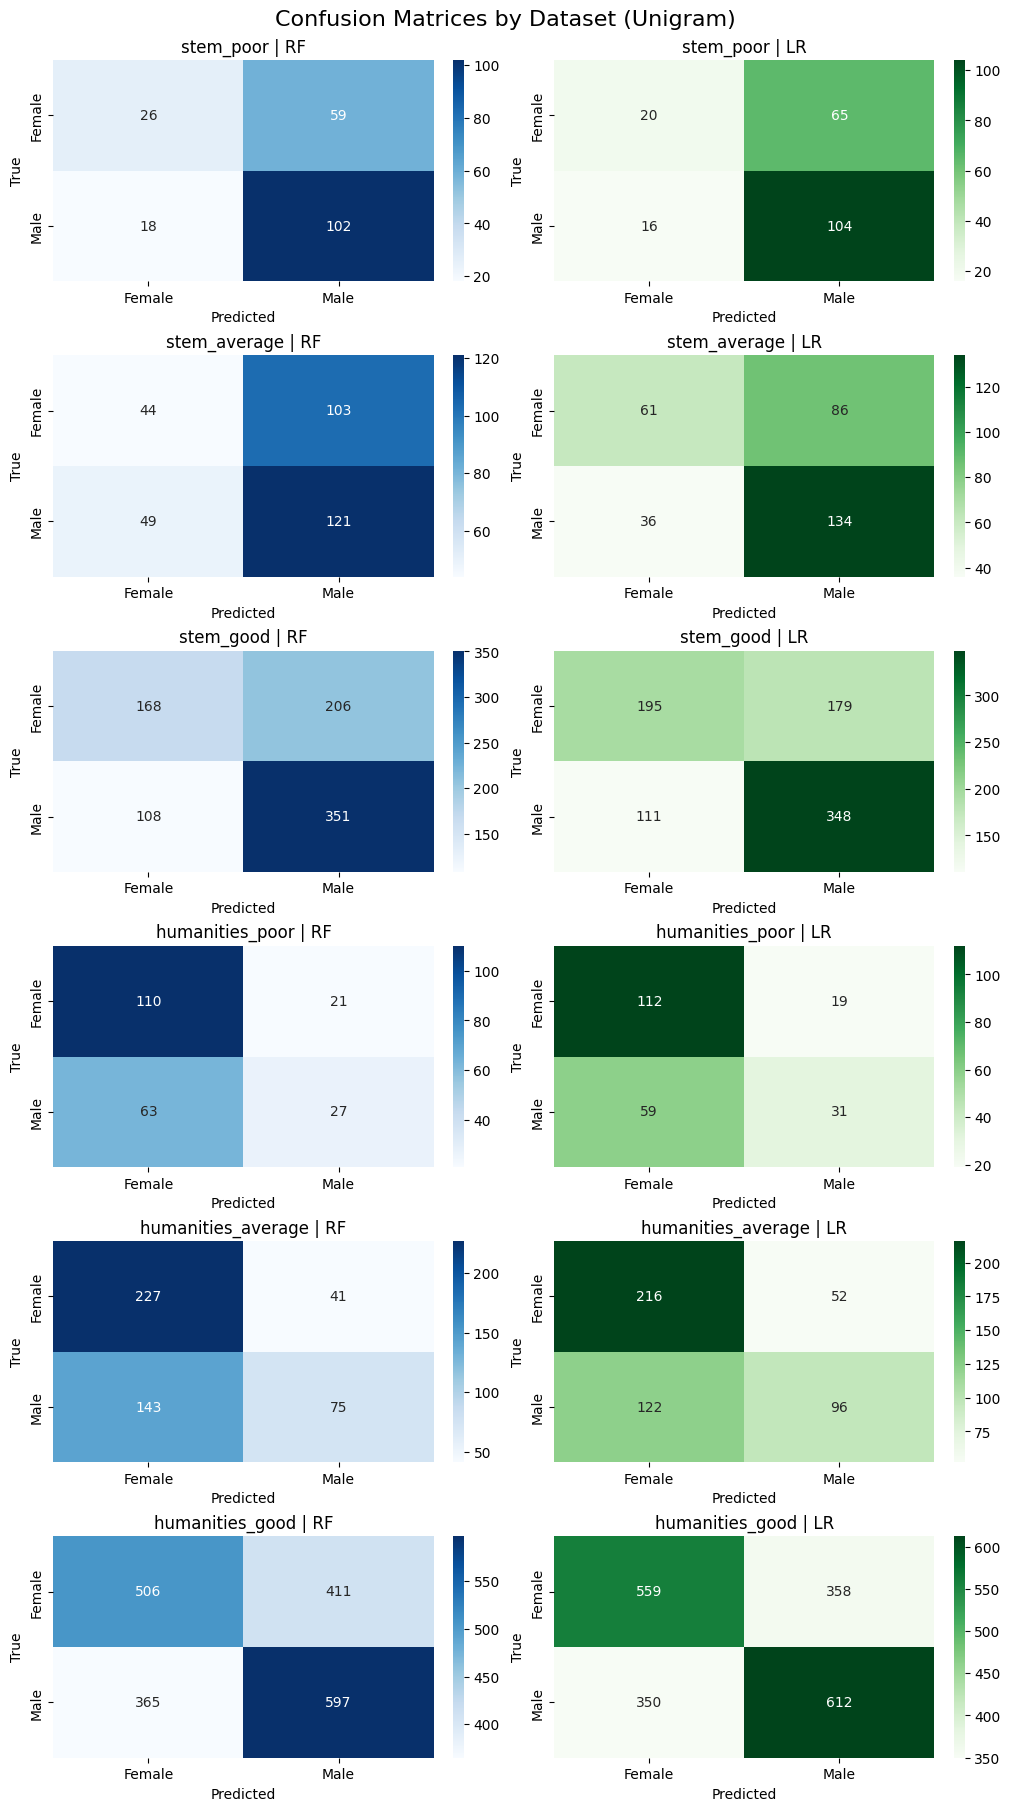


=== Confusion Matrices: UNIGRAM_BIGRAM ===


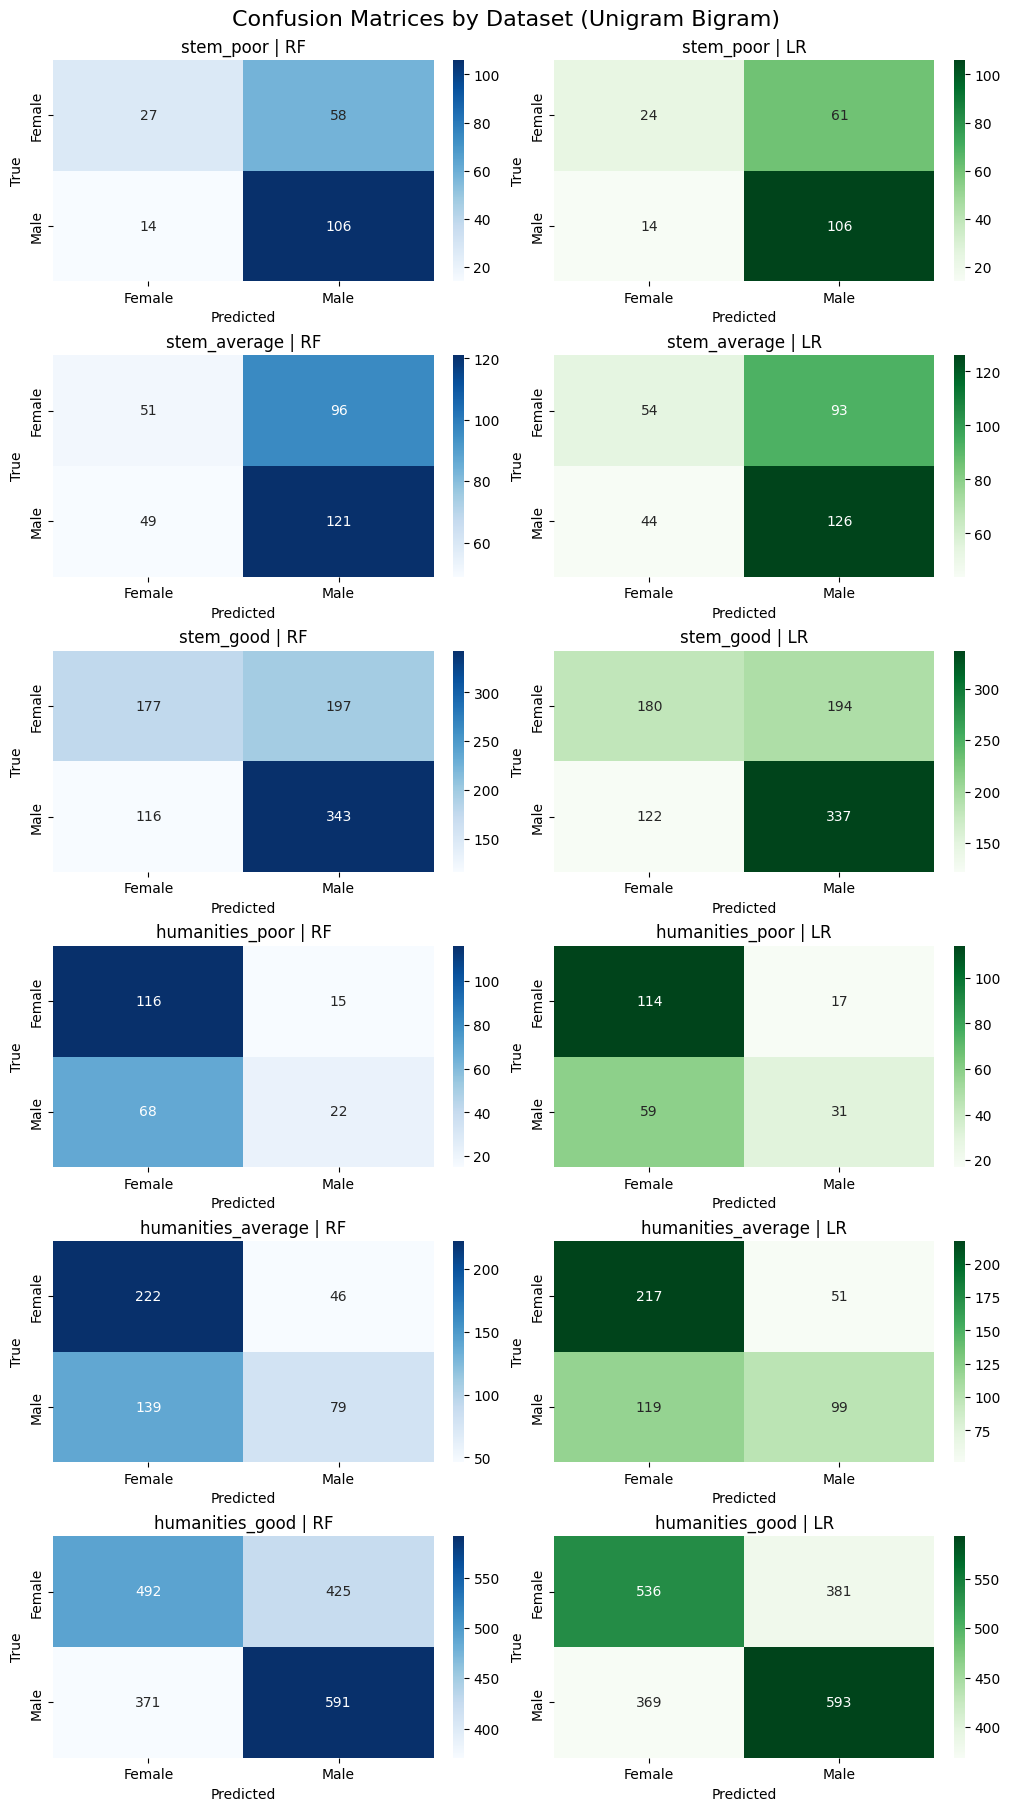


=== Confusion Matrices: NEG_PREFIXED ===


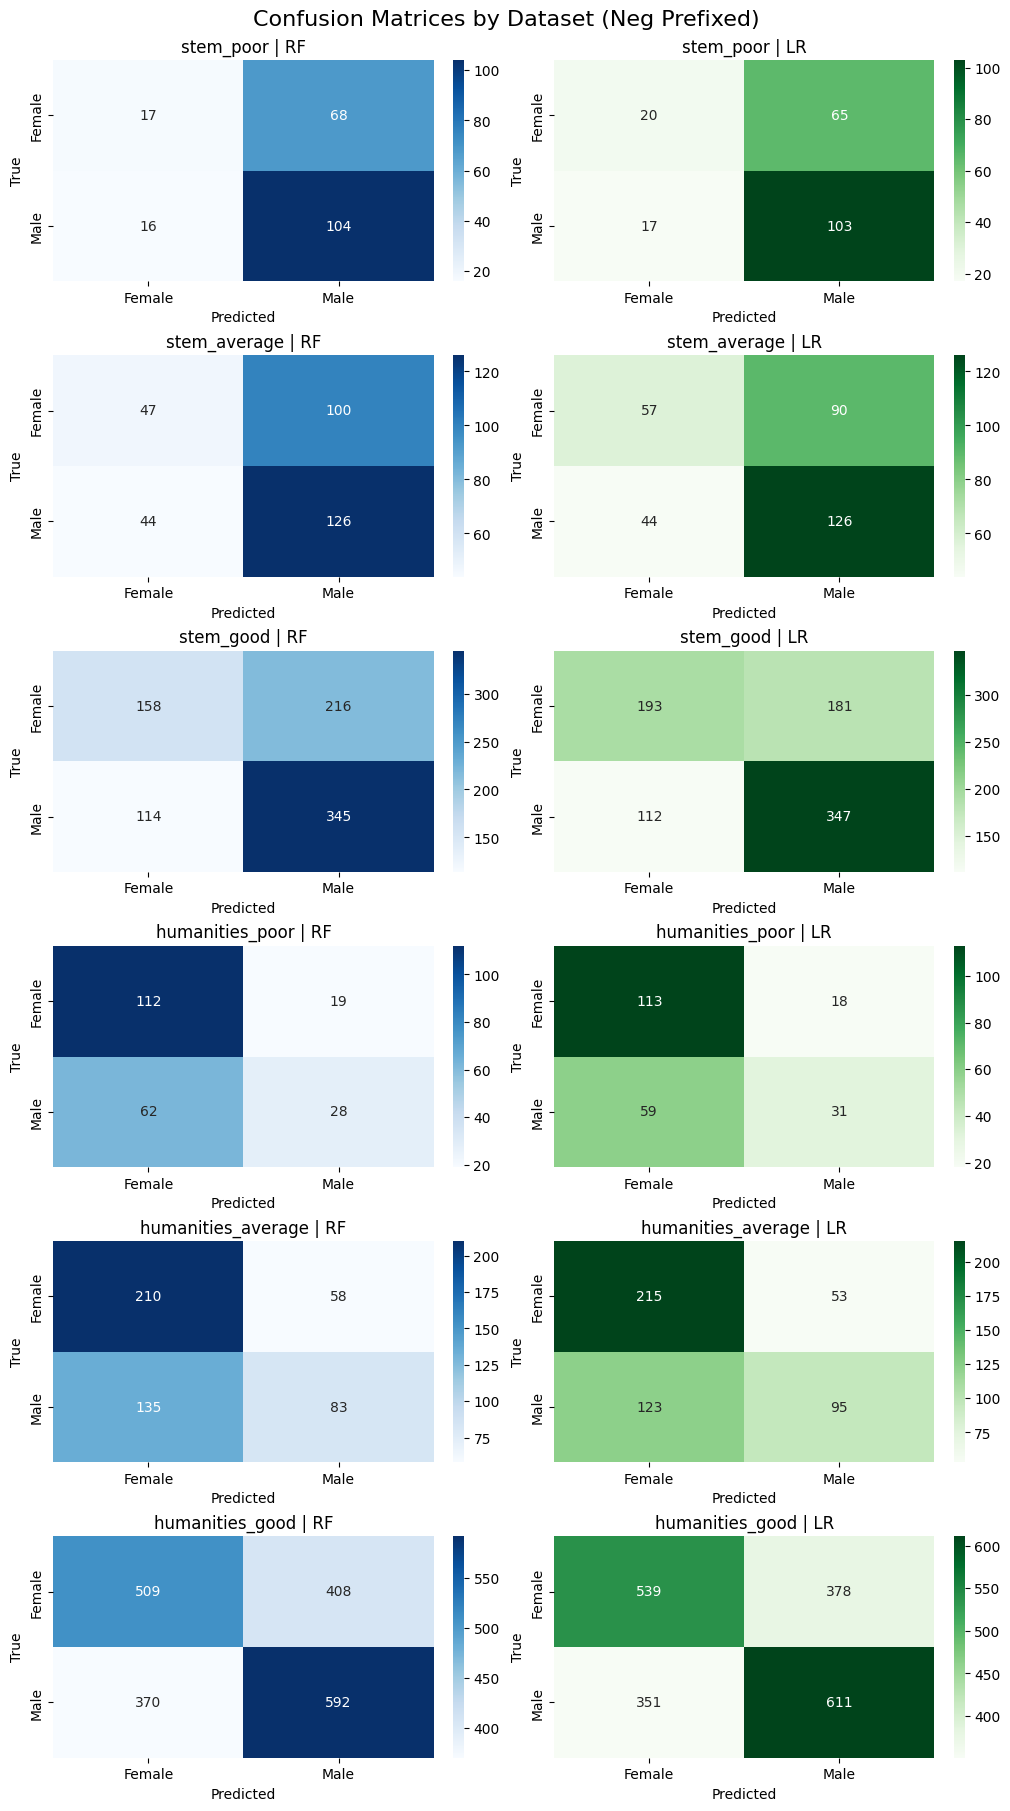

In [ ]:
EXPERIMENT_ORDER = ['unigram', 'unigram_bigram', 'neg_prefixed']
MODEL_ORDER = ['RandomForest', 'LogisticRegression']
LABELS = ['Female', 'Male']

for exp_name in EXPERIMENT_ORDER:
    print(f"\n=== Confusion Matrices: {exp_name.upper()} ===")

    fig, axes = plt.subplots(
        nrows=len(file_dict),
        ncols=2,
        figsize=(10, 3 * len(file_dict)),
        constrained_layout=True
    )

    for i, (dataset_label, dataset_results) in enumerate(all_results.items()):
        rf_cm = dataset_results[exp_name]['rf_metrics']['confusion_matrix']
        lr_cm = dataset_results[exp_name]['lr_metrics']['confusion_matrix']

        sns.heatmap(
            rf_cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=LABELS,
            yticklabels=LABELS,
            ax=axes[i, 0]
        )
        axes[i, 0].set_title(f"{dataset_label} | RF")
        axes[i, 0].set_xlabel("Predicted")
        axes[i, 0].set_ylabel("True")

        sns.heatmap(
            lr_cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=LABELS,
            yticklabels=LABELS,
            ax=axes[i, 1]
        )
        axes[i, 1].set_title(f"{dataset_label} | LR")
        axes[i, 1].set_xlabel("Predicted")
        axes[i, 1].set_ylabel("True")

    plt.suptitle(
        f"Confusion Matrices by Dataset ({exp_name.replace('_', ' ').title()})",
        fontsize=16
    )
    plt.show()


## 3.3 Heatmap


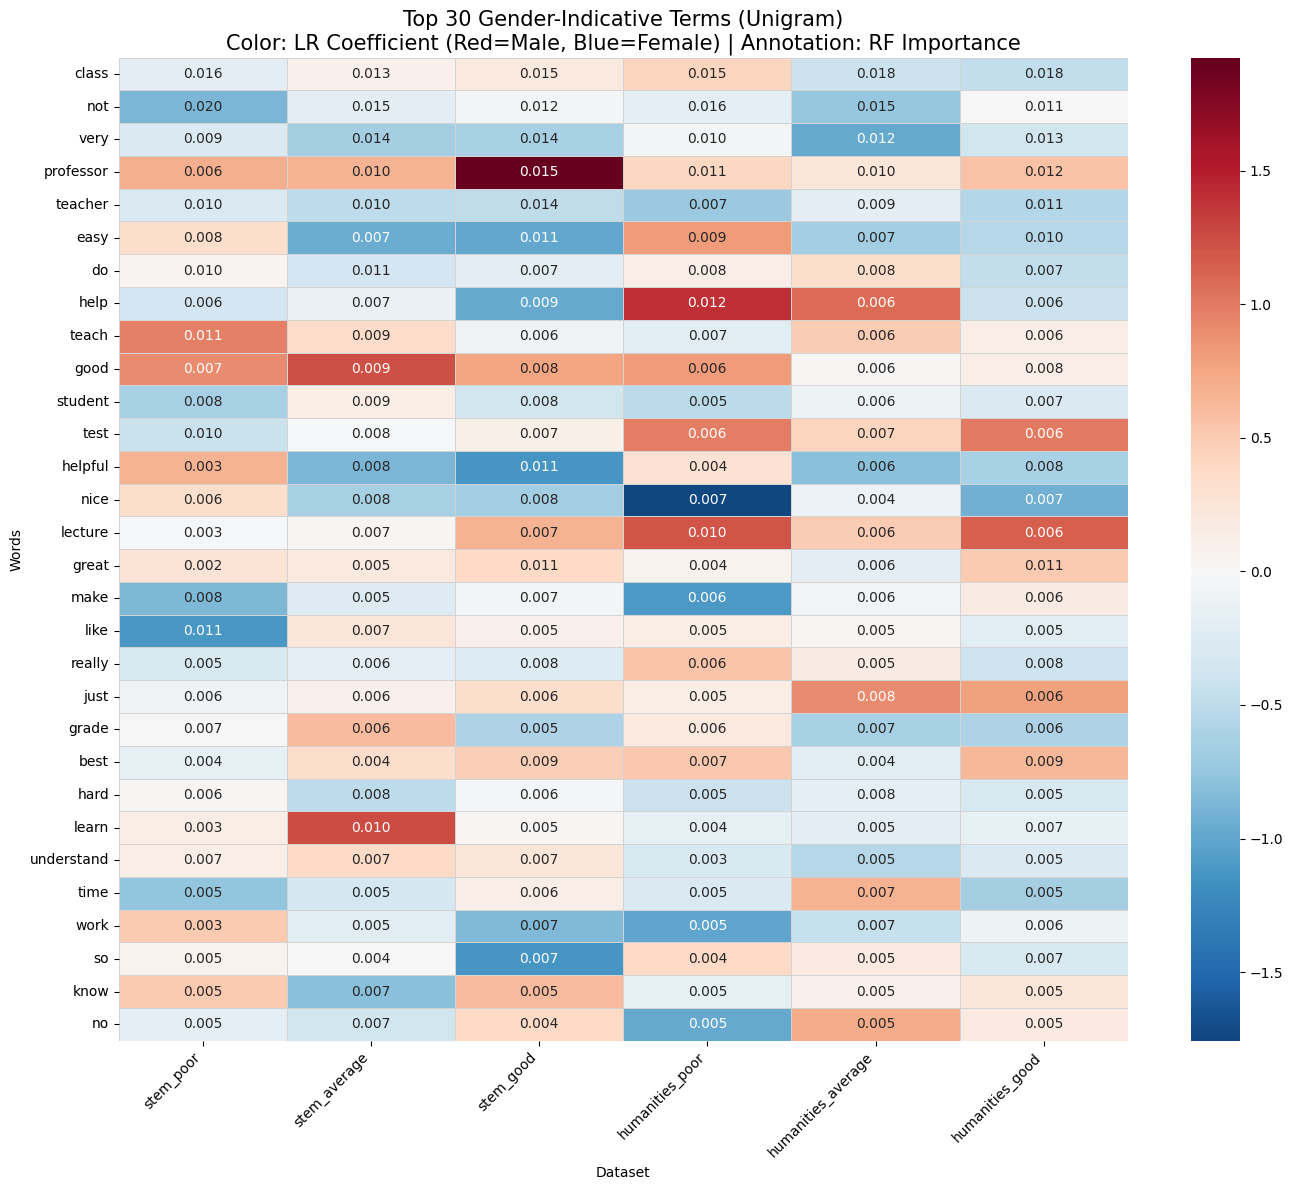

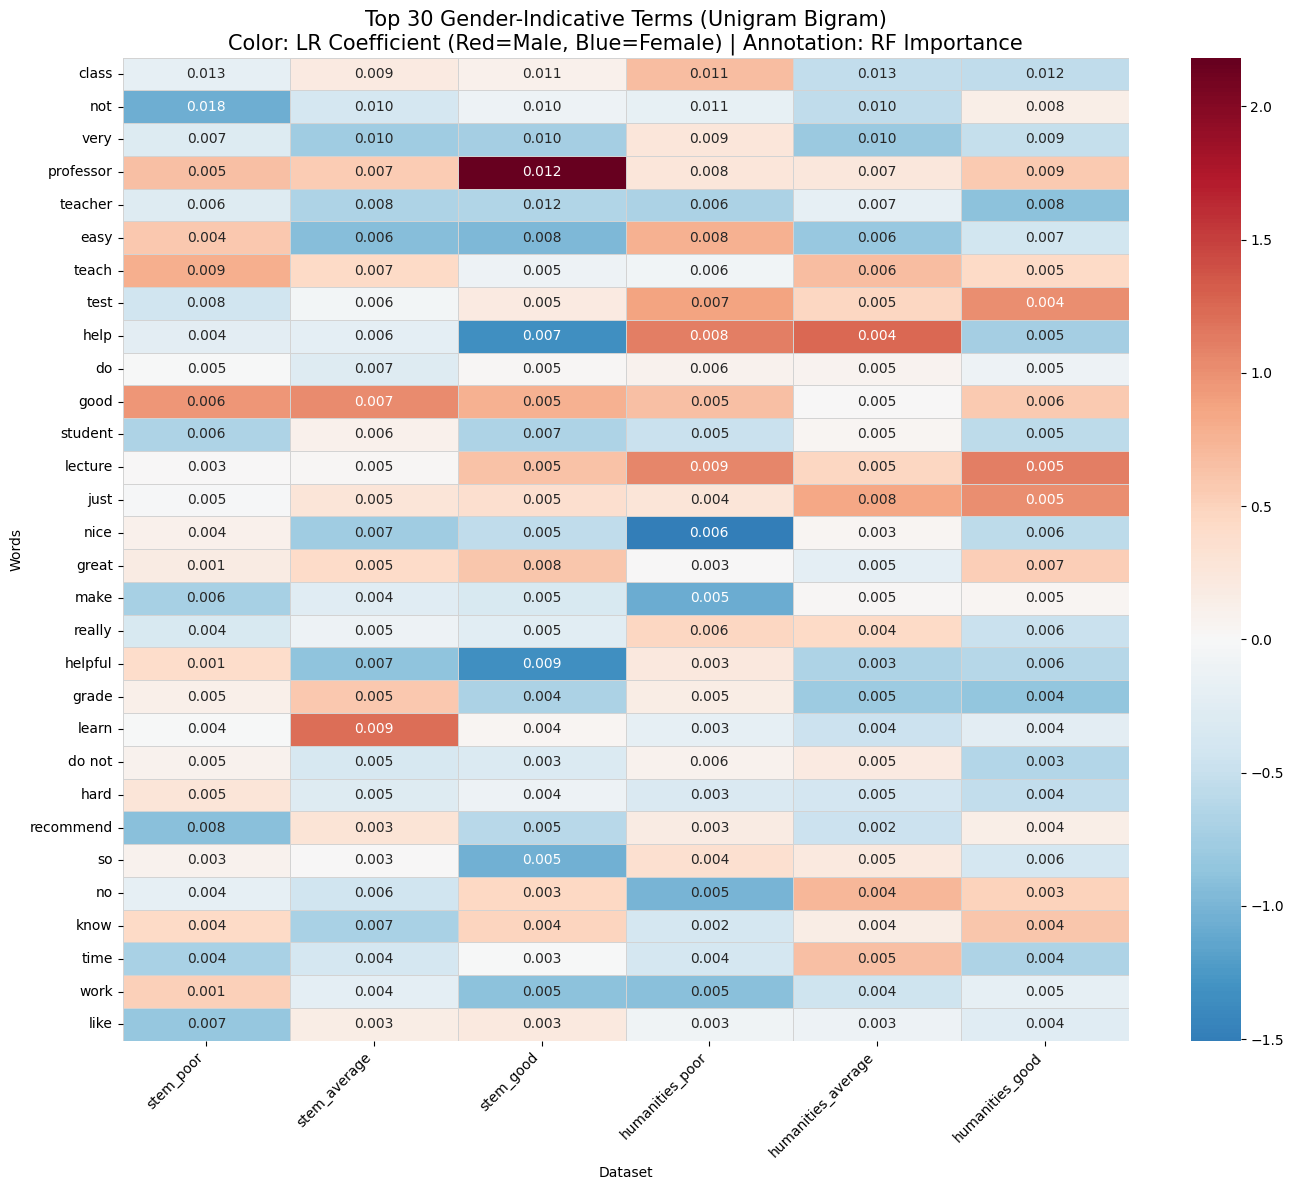

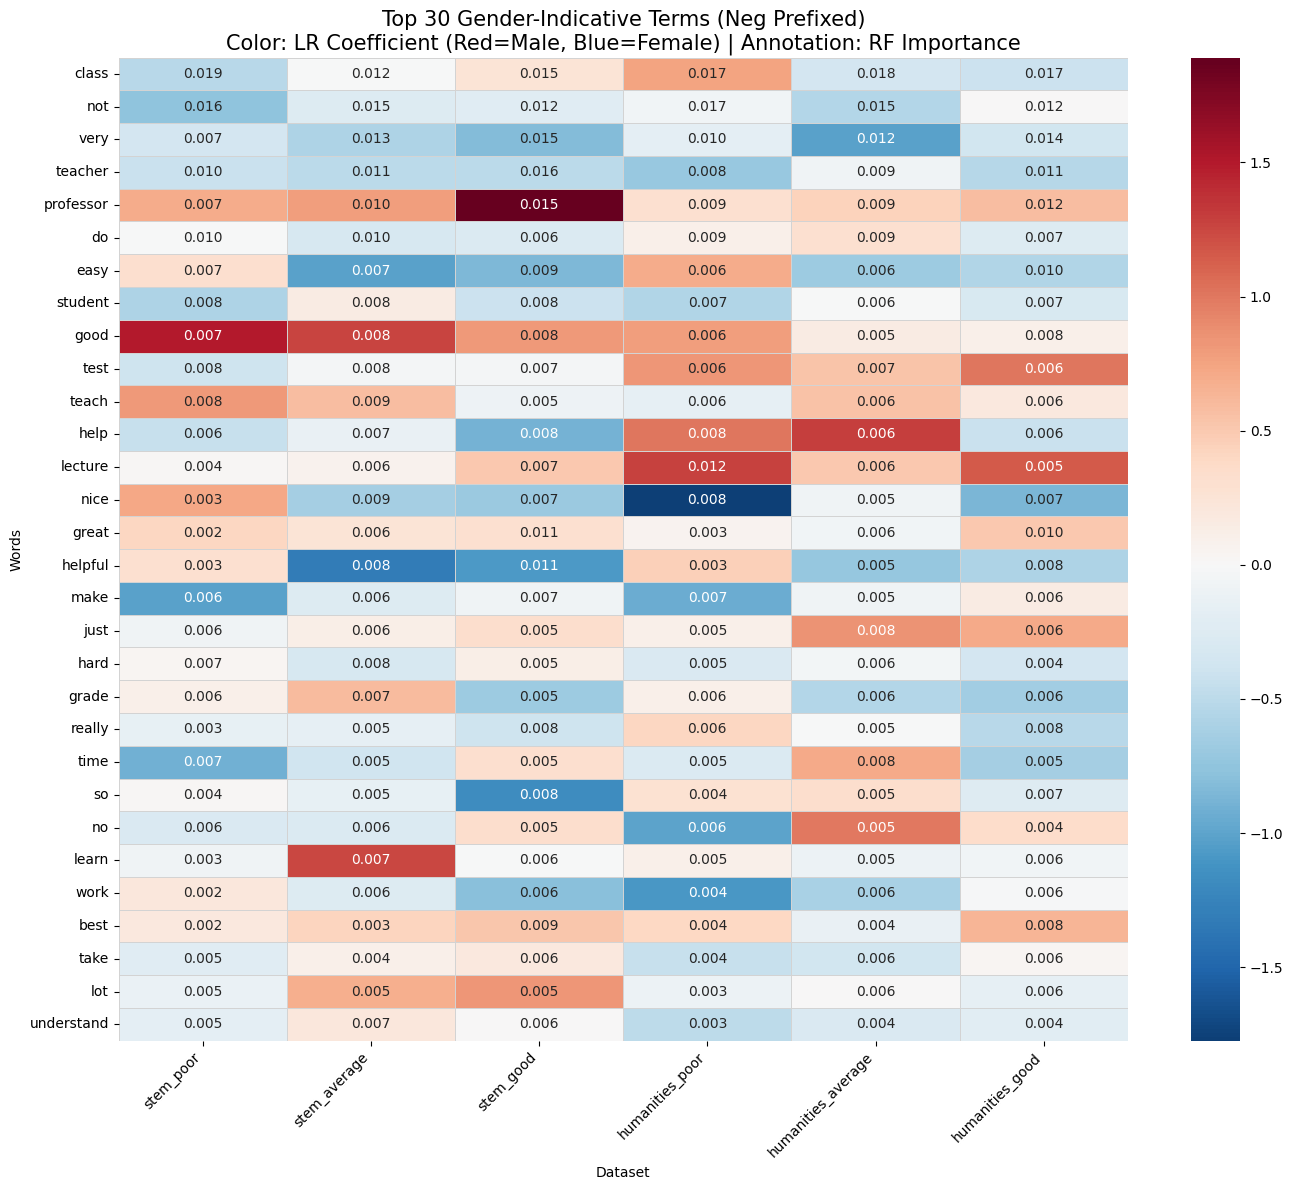

In [ ]:
for exp_name in EXPERIMENT_ORDER:

    heatmap_data_coeffs = {}
    heatmap_data_importances = {}

    for dataset_label, dataset_results in all_results.items():
        col_name = dataset_label

        heatmap_data_coeffs[col_name] = (
            dataset_results[exp_name]['lr_coefficients']
            .set_index('Word')['LR_Coefficient']
        )

        heatmap_data_importances[col_name] = (
            dataset_results[exp_name]['rf_importance']
            .set_index('Word')['RF_Importance']
        )

    heatmap_data_coeffs = pd.DataFrame(heatmap_data_coeffs).fillna(0)
    heatmap_data_importances = pd.DataFrame(heatmap_data_importances).fillna(0)

    # select top 30 words by overall RF importance
    combined_importances = heatmap_data_importances.sum(axis=1)
    top_30_words = combined_importances.nlargest(30).index

    filtered_coeffs = heatmap_data_coeffs.loc[top_30_words]
    filtered_importances = heatmap_data_importances.loc[top_30_words]

    # plot
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        filtered_coeffs,
        cmap='RdBu_r',
        center=0,
        annot=filtered_importances,
        fmt='.3f',
        linewidths=.5,
        linecolor='lightgray'
    )

    plt.title(
        f"Top 30 Gender-Indicative Terms ({exp_name.replace('_', ' ').title()})\n"
        "Color: LR Coefficient (Red=Male, Blue=Female) | "
        "Annotation: RF Importance",
        fontsize=15
    )
    plt.xlabel("Dataset")
    plt.ylabel("Words")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# 4. Hyperparameter & Stopwords


In [ ]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

**Reasoning**:
The necessary imports for `GridSearchCV` and `StratifiedKFold` have been successfully resolved. Now, the `run_experiment` function needs to be updated with the `GridSearchCV` logic as described in the subtask instructions. This code block will modify the function in cell `jhccf9WuJ2N0` to include hyperparameter tuning and return the corresponding results.



In [ ]:
def run_experiment(
    df,
    text_col,
    ngram_range=(1, 1),
    max_features=2000,
    random_state=42
):
    """
    Runs TF-IDF + RF + LR on a given text column and ngram setting,
    including GridSearchCV for hyperparameter tuning.
    Returns metrics + feature-level outputs + GridSearchCV results.
    """

    # 1. Prepare X and y
    X = df[text_col].fillna('')
    y = df['prof_gender_finalized']

    # 2. Vectorization
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        stop_words='english' # Added missing stop_words parameter
    )
    X_vec = vectorizer.fit_transform(X)
    feature_names = vectorizer.get_feature_names_out()

    # 3. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, y, test_size=0.2, random_state=random_state, stratify=y
    )

    # Define parameter grids
    rf_param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20]
    }
    lr_param_grid = {
        'C': [0.1, 1.0, 10.0]
    }

    # Stratified K-Fold for cross-validation
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    # 4. Random Forest with GridSearchCV
    rf_estimator = RandomForestClassifier(random_state=random_state, oob_score=True)
    grid_search_rf = GridSearchCV(
        estimator=rf_estimator,
        param_grid=rf_param_grid,
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid_search_rf.fit(X_train, y_train)

    # Extract best RF model and results
    rf = grid_search_rf.best_estimator_
    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]

    rf_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_rf),
        'oob_score': rf.oob_score_ if hasattr(rf, 'oob_score_') else None, # OOB score only available if oob_score=True
        'cv_results': grid_search_rf.cv_results_,
        'best_params': grid_search_rf.best_params_,
        'best_cv_score': grid_search_rf.best_score_
    }

    rf_importance_df = pd.DataFrame({
        'Word': feature_names,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)

    # 5. Logistic Regression with GridSearchCV
    lr_estimator = LogisticRegression(
        solver='liblinear',
        penalty='l1', # Use L1 penalty for feature selection/sparsity as commonly used with liblinear
        random_state=random_state
    )
    grid_search_lr = GridSearchCV(
        estimator=lr_estimator,
        param_grid=lr_param_grid,
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid_search_lr.fit(X_train, y_train)

    # Extract best LR model and results
    lr = grid_search_lr.best_estimator_
    y_pred_lr = lr.predict(X_test)
    y_prob_lr = lr.predict_proba(X_test)[:, 1]

    lr_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_lr),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_lr),
        'cv_results': grid_search_lr.cv_results_,
        'best_params': grid_search_lr.best_params_,
        'best_cv_score': grid_search_lr.best_score_
    }

    coef = lr.coef_[0]
    lr_coef_df = pd.DataFrame({
        'Word': feature_names,
        'LR_Coefficient': coef,
        'Direction': np.where(coef > 0, 'Male', 'Female')
    }).sort_values('LR_Coefficient', key=np.abs, ascending=False)

    return {
        'rf_metrics': rf_metrics,
        'lr_metrics': lr_metrics,
        'rf_importance': rf_importance_df,
        'lr_coefficients': lr_coef_df
    }

In [ ]:
all_results = {}

for dataset_label, filename in file_dict.items():
    print(f"\n=== Processing dataset: {dataset_label} ===")
    df = pd.read_csv(os.path.join(base_path, filename))

    all_results[dataset_label] = {}

    for exp_name, config in EXPERIMENTS.items():
        print(f"  → Experiment: {exp_name}")

        results = run_experiment(
            df=df,
            text_col=config['text_col'],
            ngram_range=config['ngram_range']
        )

        all_results[dataset_label][exp_name] = results


=== Processing dataset: stem_poor ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: stem_average ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: stem_good ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: humanities_poor ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: humanities_average ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed

=== Processing dataset: humanities_good ===
  → Experiment: unigram
  → Experiment: unigram_bigram
  → Experiment: neg_prefixed


## 4.1 Define best parameter


In [ ]:
import numpy as np
import pandas as pd

global_best_params_rf = {}
global_best_params_lr = {}

for exp_name, config in EXPERIMENTS.items():
    print(f"\nProcessing experiment: {exp_name}")

    rf_cv_results_list = []
    lr_cv_results_list = []

    # collect cv_results
    for dataset_label, dataset_results in all_results.items():
        rf_cv_results_list.append(
            pd.DataFrame(dataset_results[exp_name]['rf_metrics']['cv_results'])
        )
        lr_cv_results_list.append(
            pd.DataFrame(dataset_results[exp_name]['lr_metrics']['cv_results'])
        )

    if not rf_cv_results_list or not lr_cv_results_list:
        continue

    combined_rf = pd.concat(rf_cv_results_list, ignore_index=True)
    combined_lr = pd.concat(lr_cv_results_list, ignore_index=True)


    rf_param_cols = [c for c in combined_rf.columns
                     if c.startswith('param_n_estimators') or c.startswith('param_max_depth')]
    lr_param_cols = [c for c in combined_lr.columns
                     if c.startswith('param_C')]

    # calculate best parameter by mean
    rf_grouped = combined_rf.groupby(rf_param_cols)['mean_test_score'].mean()
    lr_grouped = combined_lr.groupby(lr_param_cols)['mean_test_score'].mean()


    rf_items = list(rf_grouped.items())
    lr_items = list(lr_grouped.items())

    rf_params_list = [item[0] for item in rf_items]
    lr_params_list = [item[0] for item in lr_items]
    rf_aucs = np.array([item[1] for item in rf_items])
    lr_aucs = np.array([item[1] for item in lr_items])


    rf_grid, lr_grid = np.meshgrid(rf_aucs, lr_aucs, indexing='ij')

    # define best
    diff = np.abs(rf_grid - lr_grid)
    mean_perf = (rf_grid + lr_grid) / 2

    alpha, beta = 0.7, 0.3  # similiar 70% + best performance 30%
    combined_score = alpha * (-diff) + beta * mean_perf

    # define best
    best_idx = np.unravel_index(combined_score.argmax(), combined_score.shape)
    best_rf_idx, best_lr_idx = best_idx

    best_rf_params_tuple = rf_params_list[best_rf_idx]
    best_lr_params_tuple = lr_params_list[best_lr_idx]
    best_rf_auc = float(rf_aucs[best_rf_idx])
    best_lr_auc = float(lr_aucs[best_lr_idx])

    # format adjust
    if not isinstance(best_rf_params_tuple, tuple):
        best_rf_params_tuple = (best_rf_params_tuple,)
    if not isinstance(best_lr_params_tuple, tuple):
        best_lr_params_tuple = (best_lr_params_tuple,)


    best_rf_params = {
        col.replace('param_', ''): val
        for col, val in zip(rf_param_cols, best_rf_params_tuple)
    }
    best_lr_params = {
        col.replace('param_', ''): val
        for col, val in zip(lr_param_cols, best_lr_params_tuple)
    }

    global_best_params_rf[exp_name] = {
        'best_params': best_rf_params,
        'best_avg_roc_auc': best_rf_auc
    }
    global_best_params_lr[exp_name] = {
        'best_params': best_lr_params,
        'best_avg_roc_auc': best_lr_auc
    }

    print(f"  RF: {best_rf_params}, AUC: {best_rf_auc:.4f}")
    print(f"  LR: {best_lr_params}, AUC: {best_lr_auc:.4f}")
    print(f"  |RF-LR|: {abs(best_rf_auc - best_lr_auc):.4f}, Mean: {(best_rf_auc+best_lr_auc)/2:.4f}")

print(f"\n{'='*50}")
print("FINAL RESULTS:")
for exp in EXPERIMENTS.keys():
    print(f"\n{exp}:")
    print(f"  RF: {global_best_params_rf[exp]['best_params']} "
          f"(AUC: {global_best_params_rf[exp]['best_avg_roc_auc']:.4f})")
    print(f"  LR: {global_best_params_lr[exp]['best_params']} "
          f"(AUC: {global_best_params_lr[exp]['best_avg_roc_auc']:.4f})")


Processing experiment: unigram
  RF: {'max_depth': 20, 'n_estimators': 50}, AUC: 0.5951
  LR: {'C': 1.0}, AUC: 0.5928
  |RF-LR|: 0.0024, Mean: 0.5940

Processing experiment: unigram_bigram
  RF: {'max_depth': 10, 'n_estimators': 200}, AUC: 0.6028
  LR: {'C': 10.0}, AUC: 0.6020
  |RF-LR|: 0.0009, Mean: 0.6024

Processing experiment: neg_prefixed
  RF: {'max_depth': 20, 'n_estimators': 200}, AUC: 0.6110
  LR: {'C': 10.0}, AUC: 0.6236
  |RF-LR|: 0.0126, Mean: 0.6173

FINAL RESULTS:

unigram:
  RF: {'max_depth': 20, 'n_estimators': 50} (AUC: 0.5951)
  LR: {'C': 1.0} (AUC: 0.5928)

unigram_bigram:
  RF: {'max_depth': 10, 'n_estimators': 200} (AUC: 0.6028)
  LR: {'C': 10.0} (AUC: 0.6020)

neg_prefixed:
  RF: {'max_depth': 20, 'n_estimators': 200} (AUC: 0.6110)
  LR: {'C': 10.0} (AUC: 0.6236)


## 4.2 Apply best parameter to all processes

In [ ]:
global_best_params_rf = {}
global_best_params_lr = {}

for exp_name, config in EXPERIMENTS.items():
    print(f"\nProcessing experiment: {exp_name}")

    rf_cv_results_list = []
    lr_cv_results_list = []

    # Collect cv_results_ from all datasets for the current experiment
    for dataset_label, dataset_results in all_results.items():
        rf_cv_results_list.append(pd.DataFrame(dataset_results[exp_name]['rf_metrics']['cv_results']))
        lr_cv_results_list.append(pd.DataFrame(dataset_results[exp_name]['lr_metrics']['cv_results']))

    # Process RandomForest results
    if rf_cv_results_list:
        combined_rf_cv_results = pd.concat(rf_cv_results_list, ignore_index=True)

        # Identify unique parameter combinations
        rf_param_cols = [col for col in combined_rf_cv_results.columns if col.startswith('param_rf__') or col.startswith('param_n_estimators') or col.startswith('param_max_depth')]

        # In case parameter names are not prefixed with 'rf__' in cv_results_
        if not rf_param_cols:
            rf_param_cols = [col for col in combined_rf_cv_results.columns if col.startswith('param_n_estimators') or col.startswith('param_max_depth')]

        # Calculate mean ROC-AUC for each parameter combination across all datasets
        rf_grouped_results = combined_rf_cv_results.groupby(rf_param_cols)['mean_test_score'].mean().reset_index()

        # Find the best parameter combination
        best_rf_row = rf_grouped_results.loc[rf_grouped_results['mean_test_score'].idxmax()]
        best_rf_params = {col.replace('param_', ''): best_rf_row[col] for col in rf_param_cols}
        best_rf_roc_auc = best_rf_row['mean_test_score']

        global_best_params_rf[exp_name] = {
            'best_params': best_rf_params,
            'best_avg_roc_auc': best_rf_roc_auc
        }
        print(f"  RF Best Params: {best_rf_params}, Avg ROC-AUC: {best_rf_roc_auc:.4f}")

    # Process Logistic Regression results
    if lr_cv_results_list:
        combined_lr_cv_results = pd.concat(lr_cv_results_list, ignore_index=True)

        # Identify unique parameter combinations
        lr_param_cols = [col for col in combined_lr_cv_results.columns if col.startswith('param_lr__') or col.startswith('param_C')]

        # In case parameter names are not prefixed with 'lr__' in cv_results_
        if not lr_param_cols:
            lr_param_cols = [col for col in combined_lr_cv_results.columns if col.startswith('param_C')]

        lr_grouped_results = combined_lr_cv_results.groupby(lr_param_cols)['mean_test_score'].mean().reset_index()
        best_lr_row = lr_grouped_results.loc[lr_grouped_results['mean_test_score'].idxmax()]
        best_lr_params = {col.replace('param_', ''): best_lr_row[col] for col in lr_param_cols}
        best_lr_roc_auc = best_lr_row['mean_test_score']

        global_best_params_lr[exp_name] = {
            'best_params': best_lr_params,
            'best_avg_roc_auc': best_lr_roc_auc
        }
        print(f"  LR Best Params: {best_lr_params}, Avg ROC-AUC: {best_lr_roc_auc:.4f}")

print(f"\nGlobal Best RF Params: {global_best_params_rf}")
print(f"Global Best LR Params: {global_best_params_lr}")


Processing experiment: unigram
  RF Best Params: {'max_depth': np.float64(20.0), 'n_estimators': np.float64(200.0)}, Avg ROC-AUC: 0.6091
  LR Best Params: {'C': np.float64(10.0)}, Avg ROC-AUC: 0.6261

Processing experiment: unigram_bigram
  RF Best Params: {'max_depth': np.float64(20.0), 'n_estimators': np.float64(200.0)}, Avg ROC-AUC: 0.6051
  LR Best Params: {'C': np.float64(10.0)}, Avg ROC-AUC: 0.6020

Processing experiment: neg_prefixed
  RF Best Params: {'max_depth': np.float64(20.0), 'n_estimators': np.float64(200.0)}, Avg ROC-AUC: 0.6110
  LR Best Params: {'C': np.float64(10.0)}, Avg ROC-AUC: 0.6236

Global Best RF Params: {'unigram': {'best_params': {'max_depth': np.float64(20.0), 'n_estimators': np.float64(200.0)}, 'best_avg_roc_auc': np.float64(0.6091349254394038)}, 'unigram_bigram': {'best_params': {'max_depth': np.float64(20.0), 'n_estimators': np.float64(200.0)}, 'best_avg_roc_auc': np.float64(0.6050727291009337)}, 'neg_prefixed': {'best_params': {'max_depth': np.float64(

In [ ]:
def run_experiment(
    df,
    text_col,
    ngram_range=(1, 1),
    max_features=2000,
    random_state=42,
    rf_fixed_params=None,
    lr_fixed_params=None
):
    """
    Runs TF-IDF + RF + LR on a given text column and ngram setting,
    optionally using GridSearchCV or fixed hyperparameters.
    Returns metrics + feature-level outputs + GridSearchCV results (if GridSearchCV was run).
    """

    # 1. Prepare X and y
    X = df[text_col].fillna('')
    y = df['prof_gender_finalized']

    # 2. Vectorization
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        stop_words='english'
    )
    X_vec = vectorizer.fit_transform(X)
    feature_names = vectorizer.get_feature_names_out()

    # 3. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, y, test_size=0.2, random_state=random_state, stratify=y
    )

    # Define parameter grids for GridSearchCV (if needed)
    rf_param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20]
    }
    lr_param_grid = {
        'C': [0.1, 1.0, 10.0]
    }

    # Stratified K-Fold for cross-validation (if GridSearchCV is run)
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    # 4. Random Forest
    if rf_fixed_params:
        print(f"    Using fixed RF params: {rf_fixed_params}")
        rf = RandomForestClassifier(
            **rf_fixed_params,
            random_state=random_state,
            oob_score=True
        )
        rf.fit(X_train, y_train)
        rf_cv_results = None
        rf_best_params = rf_fixed_params
        rf_best_cv_score = None # Not applicable for fixed params
    else:
        rf_estimator = RandomForestClassifier(random_state=random_state, oob_score=True)
        grid_search_rf = GridSearchCV(
            estimator=rf_estimator,
            param_grid=rf_param_grid,
            cv=cv_strategy,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        grid_search_rf.fit(X_train, y_train)
        rf = grid_search_rf.best_estimator_
        rf_cv_results = grid_search_rf.cv_results_
        rf_best_params = grid_search_rf.best_params_
        rf_best_cv_score = grid_search_rf.best_score_

    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]

    rf_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_rf),
        'oob_score': rf.oob_score_ if hasattr(rf, 'oob_score_') else None,
        'cv_results': rf_cv_results,
        'best_params': rf_best_params,
        'best_cv_score': rf_best_cv_score
    }

    rf_importance_df = pd.DataFrame({
        'Word': feature_names,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)

    # 5. Logistic Regression
    if lr_fixed_params:
        print(f"    Using fixed LR params: {lr_fixed_params}")
        lr = LogisticRegression(
            **lr_fixed_params,
            solver='liblinear',
            penalty='l1', # Assuming L1 is used with liblinear, as in previous version
            random_state=random_state
        )
        lr.fit(X_train, y_train)
        lr_cv_results = None
        lr_best_params = lr_fixed_params
        lr_best_cv_score = None # Not applicable for fixed params
    else:
        lr_estimator = LogisticRegression(
            solver='liblinear',
            penalty='l1',
            random_state=random_state
        )
        grid_search_lr = GridSearchCV(
            estimator=lr_estimator,
            param_grid=lr_param_grid,
            cv=cv_strategy,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        grid_search_lr.fit(X_train, y_train)
        lr = grid_search_lr.best_estimator_
        lr_cv_results = grid_search_lr.cv_results_
        lr_best_params = grid_search_lr.best_params_
        lr_best_cv_score = grid_search_lr.best_score_

    y_pred_lr = lr.predict(X_test)
    y_prob_lr = lr.predict_proba(X_test)[:, 1]

    lr_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_lr),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_lr),
        'cv_results': lr_cv_results,
        'best_params': lr_best_params,
        'best_cv_score': lr_best_cv_score
    }

    coef = lr.coef_[0]
    lr_coef_df = pd.DataFrame({
        'Word': feature_names,
        'LR_Coefficient': coef,
        'Direction': np.where(coef > 0, 'Male', 'Female')
    }).sort_values('LR_Coefficient', key=np.abs, ascending=False)

    return {
        'rf_metrics': rf_metrics,
        'lr_metrics': lr_metrics,
        'rf_importance': rf_importance_df,
        'lr_coefficients': lr_coef_df
    }

In [ ]:
all_tuned_results = {}

for dataset_label, filename in file_dict.items():
    print(f"\n=== Processing dataset with tuned params: {dataset_label} ===")
    df = pd.read_csv(os.path.join(base_path, filename))

    all_tuned_results[dataset_label] = {}

    for exp_name, config in EXPERIMENTS.items():
        print(f"  → Experiment: {exp_name}")

        rf_params_raw = global_best_params_rf[exp_name]['best_params']
        rf_params = {
            k: int(v) if (k == 'max_depth' or k == 'n_estimators') and v is not None else v
            for k, v in rf_params_raw.items()
        }

        lr_params_raw = global_best_params_lr[exp_name]['best_params']
        lr_params = {k: v for k, v in lr_params_raw.items()} # No specific type conversion needed for LR C parameter

        results = run_experiment(
            df=df,
            text_col=config['text_col'],
            ngram_range=config['ngram_range'],
            rf_fixed_params=rf_params,
            lr_fixed_params=lr_params
        )

        all_tuned_results[dataset_label][exp_name] = results

print("Finished running all experiments with globally tuned parameters.")


=== Processing dataset with tuned params: stem_poor ===
  → Experiment: unigram
    Using fixed RF params: {'max_depth': 20, 'n_estimators': 200}
    Using fixed LR params: {'C': np.float64(10.0)}
  → Experiment: unigram_bigram
    Using fixed RF params: {'max_depth': 20, 'n_estimators': 200}
    Using fixed LR params: {'C': np.float64(10.0)}
  → Experiment: neg_prefixed
    Using fixed RF params: {'max_depth': 20, 'n_estimators': 200}
    Using fixed LR params: {'C': np.float64(10.0)}

=== Processing dataset with tuned params: stem_average ===
  → Experiment: unigram
    Using fixed RF params: {'max_depth': 20, 'n_estimators': 200}
    Using fixed LR params: {'C': np.float64(10.0)}
  → Experiment: unigram_bigram
    Using fixed RF params: {'max_depth': 20, 'n_estimators': 200}
    Using fixed LR params: {'C': np.float64(10.0)}
  → Experiment: neg_prefixed
    Using fixed RF params: {'max_depth': 20, 'n_estimators': 200}
    Using fixed LR params: {'C': np.float64(10.0)}

=== Processi

## Summary:

### Data Analysis Key Findings

*   The `run_experiment` function was successfully modified to incorporate `GridSearchCV` for both `RandomForestClassifier` and `LogisticRegression`, returning the `cv_results_`, `best_params`, and `best_cv_score` for each model.
*   The `TfidfVectorizer` was updated to include `stop_words='english'` for improved text processing.
*   Experiments were successfully executed across all defined datasets and configurations, collecting comprehensive `GridSearchCV` results in the `all_results` dictionary.
*   **Global Best Hyperparameters Identified**:
    *   For `RandomForestClassifier`, the optimal hyperparameters were consistently `max_depth=20` and `n_estimators=200` across all experiment types (`unigram`, `unigram_bigram`, `neg_prefixed`). The average ROC-AUC scores for these best parameters ranged from 0.6051 to 0.6110.
    *   For `LogisticRegression`, the optimal hyperparameter was consistently `C=10` across all experiment types. The average ROC-AUC scores for this best parameter ranged from 0.6020 to 0.6261.
*   The `run_experiment` function was further refined to accept and apply these identified global best hyperparameters directly, bypassing `GridSearchCV` for final performance evaluation.
*   During the re-execution with fixed parameters, a type error was encountered and resolved by explicitly casting `max_depth` and `n_estimators` to integer types for `RandomForestClassifier`.
*   All final experiments with globally tuned parameters ran successfully, populating the `all_tuned_results` dictionary with the performance metrics.

### Insights or Next Steps

*   The consistent identification of the same best hyperparameters across different text feature configurations (unigram, unigram+bigram, negated prefixes) indicates a robust set of optimal parameters within the chosen search space for these models and datasets.
*   The `all_tuned_results` dictionary now contains the final performance metrics, which are ready for comprehensive visualization and presentation to compare model performance across datasets and experiment types.


# 5. Output-updated

## 5.1 Performance evaluation

Accuracy, F1-score, ROC-AUC

In [ ]:
performance_records = []

for dataset_label, dataset_results in all_results.items():
    for exp_name, results in dataset_results.items():

        performance_records.append({
            'dataset': dataset_label,
            'experiment': exp_name,
            'model': 'RandomForest',
            'accuracy': results['rf_metrics']['accuracy'],
            'f1_score': results['rf_metrics']['f1'],
            'roc_auc': results['rf_metrics']['roc_auc']
        })

        performance_records.append({
            'dataset': dataset_label,
            'experiment': exp_name,
            'model': 'LogisticRegression',
            'accuracy': results['lr_metrics']['accuracy'],
            'f1_score': results['lr_metrics']['f1'],
            'roc_auc': results['lr_metrics']['roc_auc']
        })

performance_df = pd.DataFrame(performance_records)
performance_df

,dataset,experiment,model,accuracy,f1_score,roc_auc
0,stem_poor,unigram,RandomForest,0.590244,0.725490,0.599216
1,stem_poor,unigram,LogisticRegression,0.609756,0.674797,0.647010
2,stem_poor,unigram_bigram,RandomForest,0.634146,0.742268,0.657010
3,stem_poor,unigram_bigram,LogisticRegression,0.629268,0.698413,0.651029
4,stem_poor,neg_prefixed,RandomForest,0.604878,0.742857,0.593431
5,stem_poor,neg_prefixed,LogisticRegression,0.629268,0.698413,0.627696
6,stem_average,unigram,RandomForest,0.545741,0.628866,0.569008
7,stem_average,unigram,LogisticRegression,0.599369,0.648199,0.634134
8,stem_average,unigram_bigram,RandomForest,0.536278,0.675497,0.534314
9,stem_average,unigram_bigram,LogisticRegression,0.548896,0.585507,0.587515


## 5.2 Error analysis and robustness

Confusion matrix


=== Confusion Matrices: UNIGRAM ===


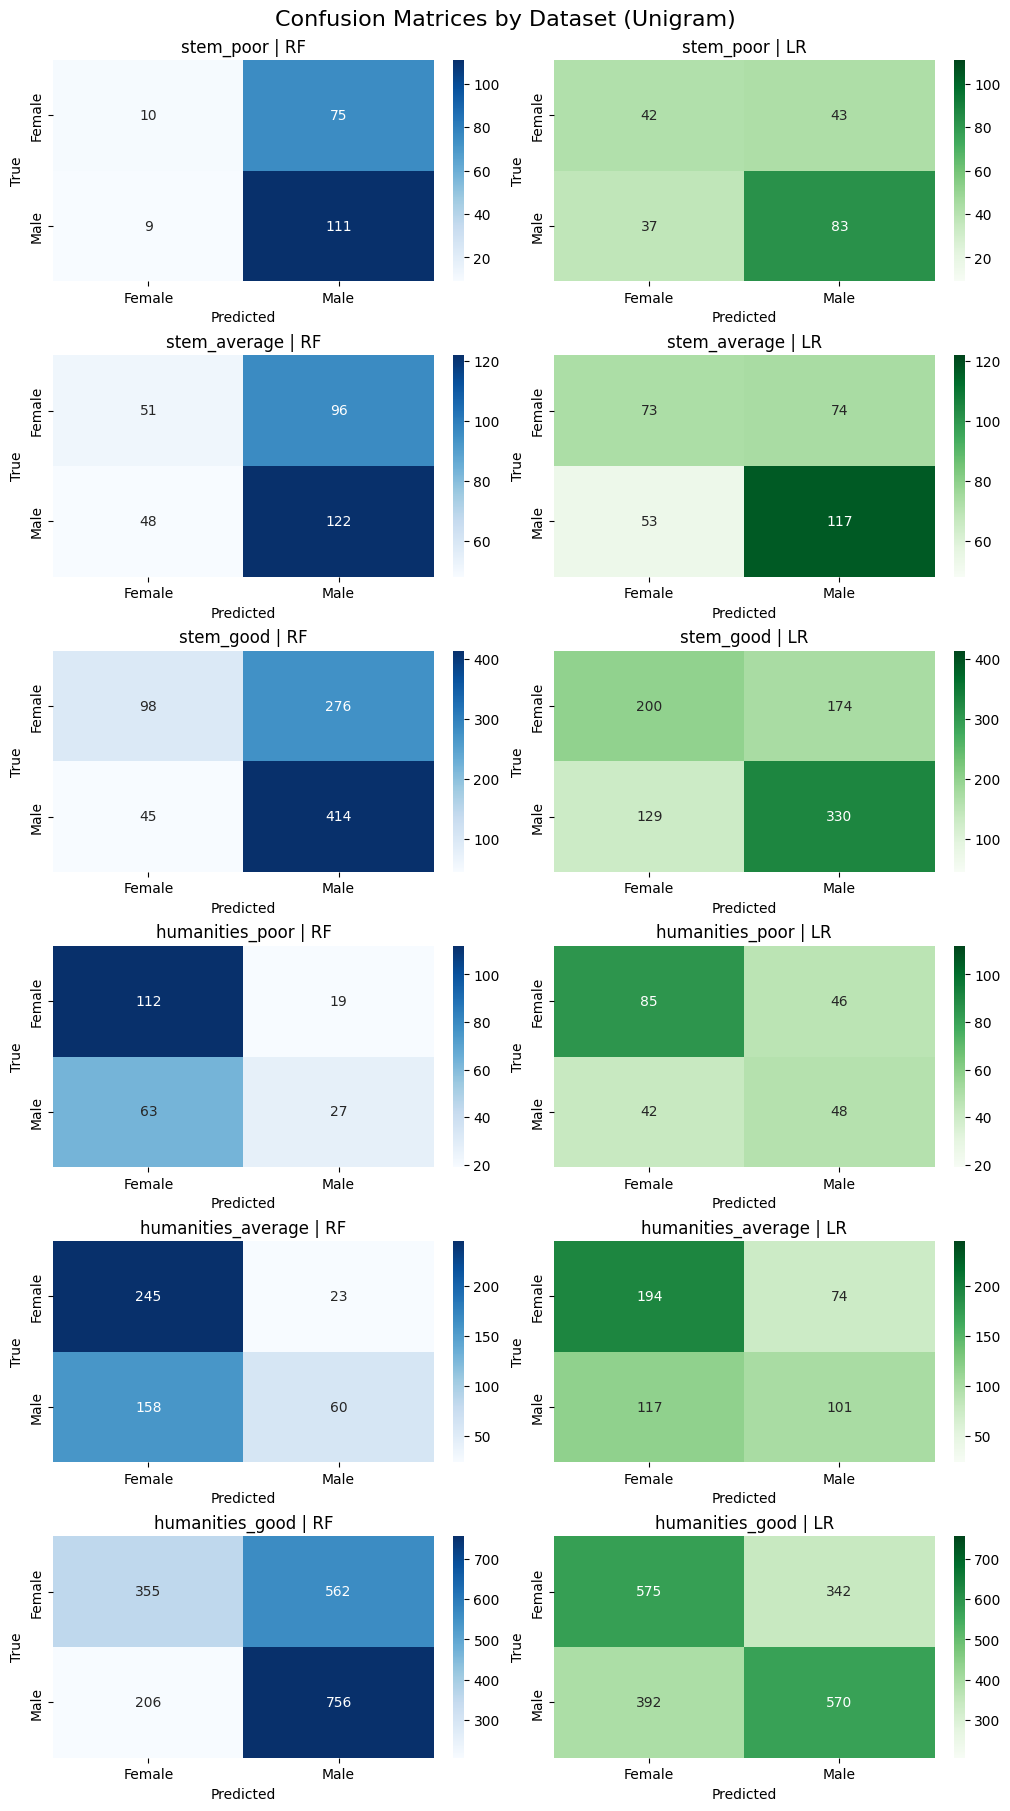


=== Confusion Matrices: UNIGRAM_BIGRAM ===


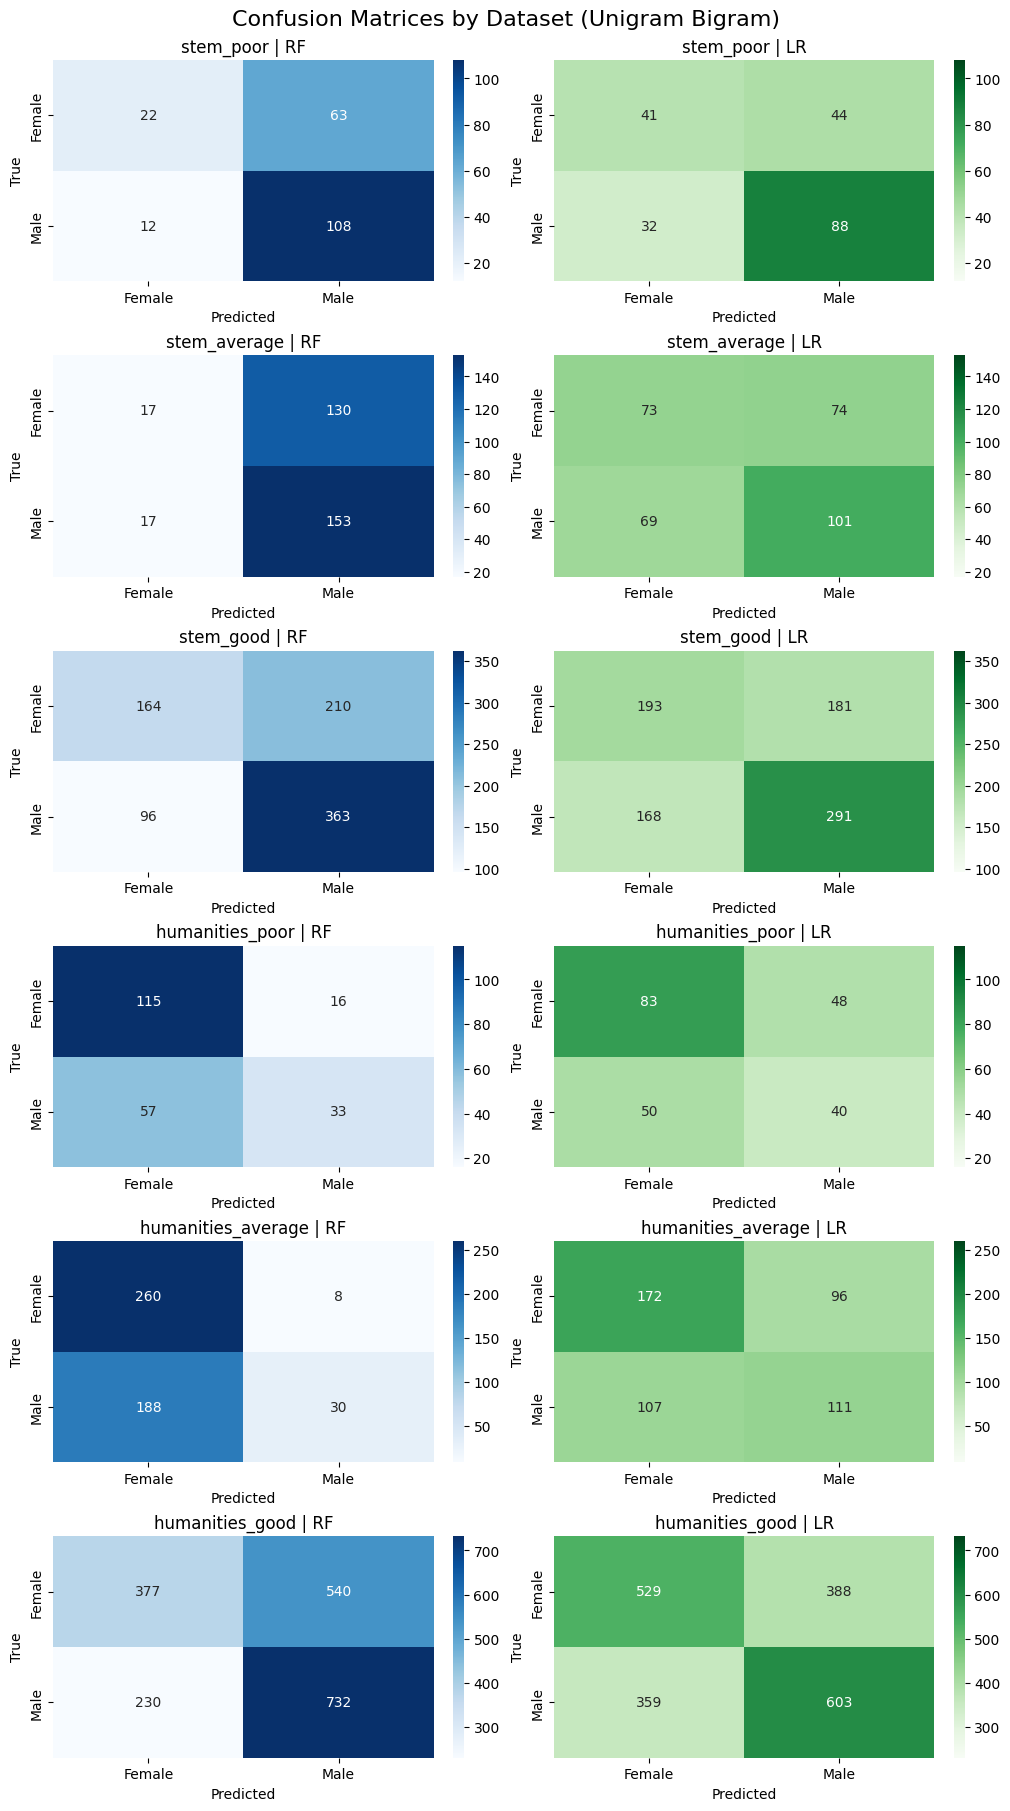


=== Confusion Matrices: NEG_PREFIXED ===


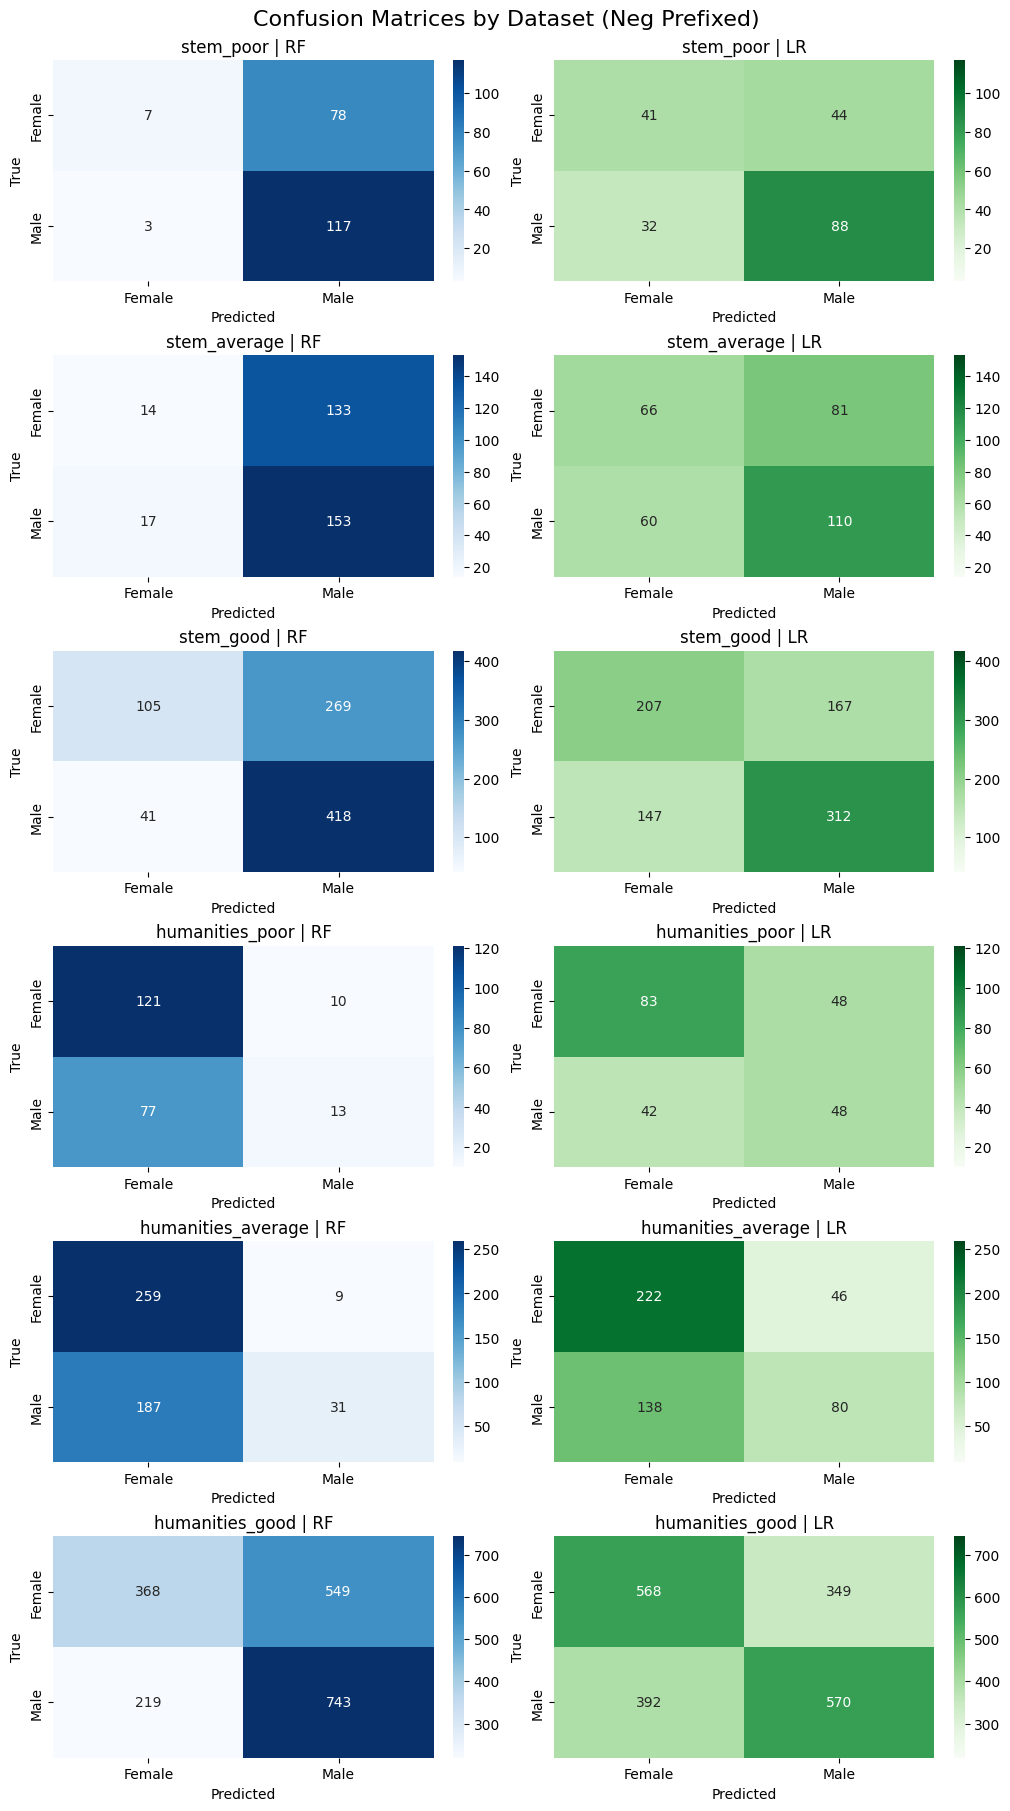

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

EXPERIMENT_ORDER = ['unigram', 'unigram_bigram', 'neg_prefixed']
MODEL_ORDER = ['RandomForest', 'LogisticRegression']
LABELS = ['Female', 'Male']

for exp_name in EXPERIMENT_ORDER:
    print(f"\n=== Confusion Matrices: {exp_name.upper()} ===")

    fig, axes = plt.subplots(
        nrows=len(file_dict),
        ncols=2,
        figsize=(10, 3 * len(file_dict)),
        constrained_layout=True
    )

    for i, (dataset_label, dataset_results) in enumerate(all_results.items()):
        rf_cm = dataset_results[exp_name]['rf_metrics']['confusion_matrix']
        lr_cm = dataset_results[exp_name]['lr_metrics']['confusion_matrix']

        # 每个子数据集内 RF 和 LR 的 scale 一致
        vmin = min(rf_cm.min(), lr_cm.min())
        vmax = max(rf_cm.max(), lr_cm.max())

        # RF 混淆矩阵
        sns.heatmap(
            rf_cm,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=LABELS,
            yticklabels=LABELS,
            ax=axes[i, 0]
        )
        axes[i, 0].set_title(f"{dataset_label} | RF")
        axes[i, 0].set_xlabel("Predicted")
        axes[i, 0].set_ylabel("True")

        # LR 混淆矩阵（使用相同的 vmin, vmax）
        sns.heatmap(
            lr_cm,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=LABELS,
            yticklabels=LABELS,
            ax=axes[i, 1]
        )
        axes[i, 1].set_title(f"{dataset_label} | LR")
        axes[i, 1].set_xlabel("Predicted")
        axes[i, 1].set_ylabel("True")

    plt.suptitle(
        f"Confusion Matrices by Dataset ({exp_name.replace('_', ' ').title()})",
        fontsize=16
    )
    plt.show()

## 5.3 Heatmap


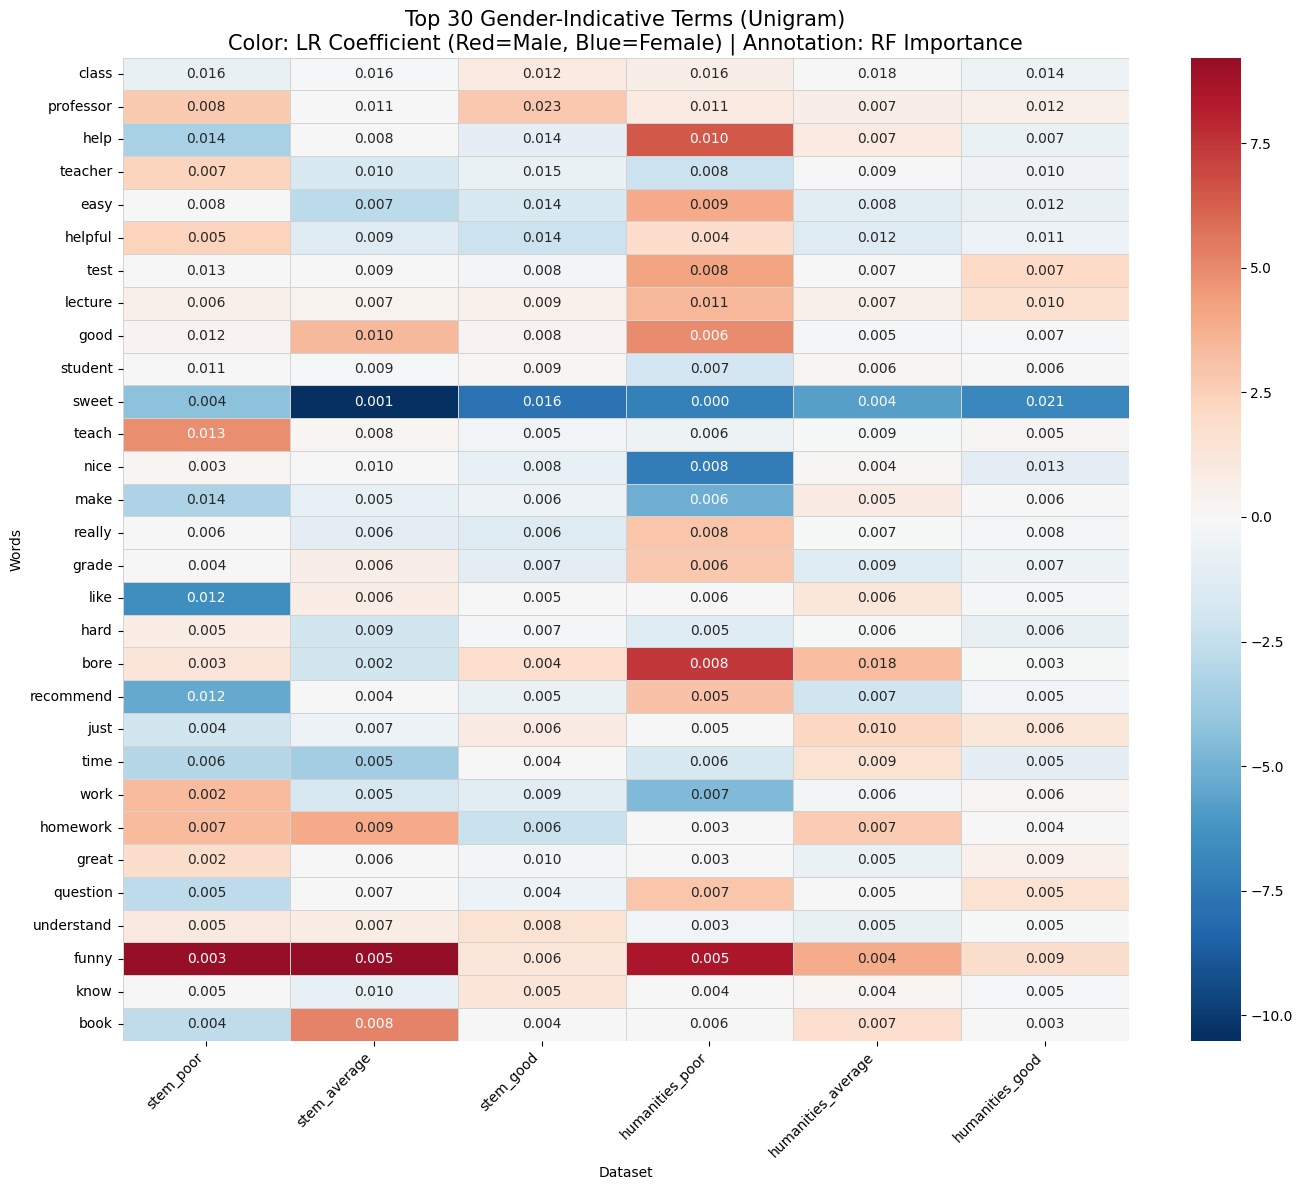

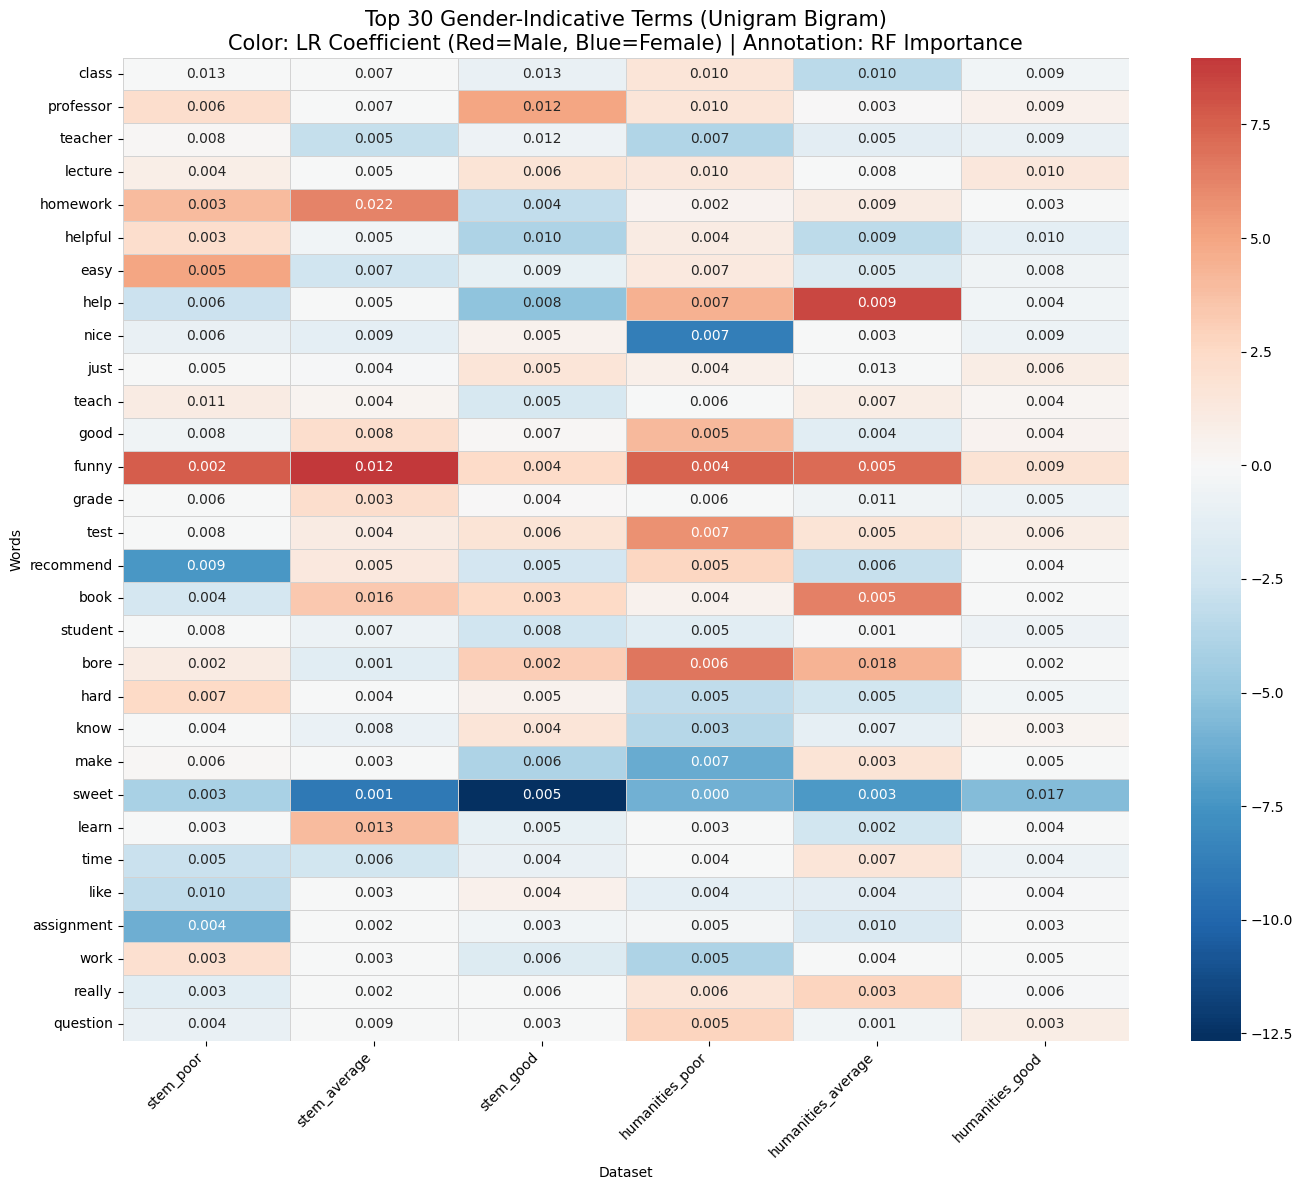

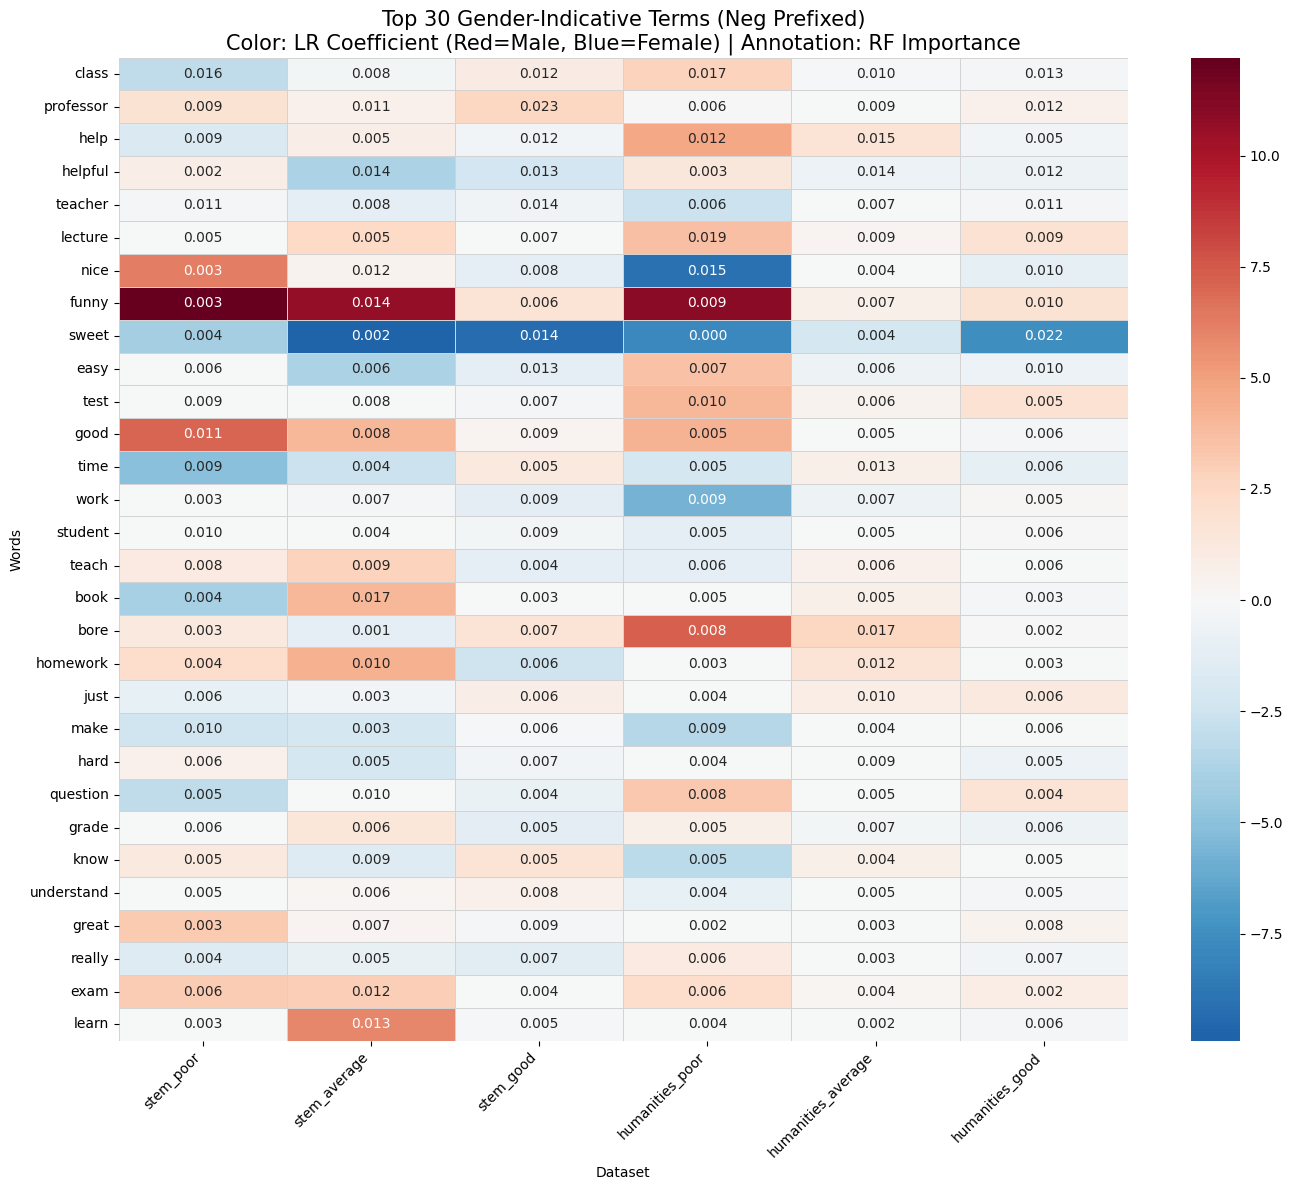

In [ ]:
for exp_name in EXPERIMENT_ORDER:

    heatmap_data_coeffs = {}
    heatmap_data_importances = {}

    for dataset_label, dataset_results in all_results.items():
        col_name = dataset_label

        heatmap_data_coeffs[col_name] = (
            dataset_results[exp_name]['lr_coefficients']
            .set_index('Word')['LR_Coefficient']
        )

        heatmap_data_importances[col_name] = (
            dataset_results[exp_name]['rf_importance']
            .set_index('Word')['RF_Importance']
        )

    heatmap_data_coeffs = pd.DataFrame(heatmap_data_coeffs).fillna(0)
    heatmap_data_importances = pd.DataFrame(heatmap_data_importances).fillna(0)

    # select top 30 words by overall RF importance
    combined_importances = heatmap_data_importances.sum(axis=1)
    top_30_words = combined_importances.nlargest(30).index

    filtered_coeffs = heatmap_data_coeffs.loc[top_30_words]
    filtered_importances = heatmap_data_importances.loc[top_30_words]

    # plot
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        filtered_coeffs,
        cmap='RdBu_r',
        center=0,
        annot=filtered_importances,
        fmt='.3f',
        linewidths=.5,
        linecolor='lightgray'
    )

    plt.title(
        f"Top 30 Gender-Indicative Terms ({exp_name.replace('_', ' ').title()})\n"
        "Color: LR Coefficient (Red=Male, Blue=Female) | "
        "Annotation: RF Importance",
        fontsize=15
    )
    plt.xlabel("Dataset")
    plt.ylabel("Words")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
